# Cryosphere model Comparison tool (CmCt) --- Calving Research

### This notebooks has been used to research pasrts about the calving comparison tool, and is not intended for end users.

The input ice sheet model needs to be provided as a netCDF file. The user may upload a single input file that includes multiple years; future enhancements to this tool will allow users to upload model ensembles.

There are several requirements for the comparison:

### Rectangular grid

At time of writing, models *must* be defined on a rectangular X-Y grid in the ISMIP6 standard projected polar-stereographic space. (Note, NOT a lat-lon grid!) The ISMIP6 standard projection is defined [here](https://theghub.org/groups/ismip6/wiki). 

### Date range


The CmCt Calving tool compares user uploaded ice sheet model to satellite calving data, derived from the   satellite missions. The CmCt reprojects modeled ice sheet mass change into calving space and performs a direct quantitative comparison, calculating model-observation discrepancies, therefore bringing the ice sheet model and calving data to the same spatial resolution for comparison.

## Calving dataset description

## Input data requirements

In [1]:
## Import modules
import os,sys
import numpy as np
import geopandas as gpd
import cftime 
import gc
import shapely
import json 
from ipywidgets import interact, FloatSlider
import ipywidgets as widgets
import matplotlib.pyplot as plt
# Add the directory containing 'cmct' to the Python path
# Navigate two levels up to reach main CmCt dir
cmct_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir))

# Initialising Logger 
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)


# Import utilities for this comparison
sys.path.insert(0,cmct_dir)
from cmct.time_utils import check_datarange
from cmct.calving import *
from cmct.calving_modules.interpolation import *
from cmct.calving_modules.json_to_netcdf import *
from cmct.shapefile_utils import *          

# Force initial garbage collection
gc.collect()


92

In [2]:
# Reload modules to pick up any changes to imports
import importlib
import cmct.calving
import cmct.shapefile_utils
importlib.reload(cmct.shapefile_utils)
importlib.reload(cmct.calving)

# Re-import to ensure functions are available
from cmct.calving import *
from cmct.shapefile_utils import *

In [3]:
# Reload modules to pick up the TypeError fix for time formats
import importlib
import cmct.calving
import cmct.time_utils
importlib.reload(cmct.time_utils)
importlib.reload(cmct.calving)

# Re-import to ensure functions are available
from cmct.calving import *
from cmct.time_utils import check_datarange

### Configuration

In [4]:
# Observation Dataset
# Ice sheet
loc = 'GIS' # 'GIS' or 'AIS'

# Set the observation data dir path
obs_filename = cmct_dir + '/data/calving/observed_icemask_ismip_annual.nc'

# To use aggregation functions for basin 
basin_aggregation = True # IMPORTANT

basin_shapes = cmct_dir + '/data/ne_10m_coastline/ne_10m_coastline.shp'

# Set the Model Data dir path
# model_filename = cmct_dir + "/test/calving/ensemble/sftgif_B001_hist.nc"
model_filename = cmct_dir + "/test/calving/sftgif_GIS_JPL_ISSM_historical.nc"

# Set time range for comparison
start_year = 2007
end_year = 2010

# List of basins (ex [NW, NE]) to compare if all -> "all"
# If you do not know which basins are in the model, you can put "auto"
# NOTE: Align this list with the basins in the model.
basin_list = "all"

# Output filetype and filename
filetype = 'netcdf' # netcdf or json or None
filename = 'calving_comparison'

# Optional Configurations 
interpolation_method = 'slinear' # 'nearest', 'linear', 'cubic'
accuracy_calculation_method = 'mean' # 'mean', 'RMS',   

colors = {
    'CW': 'blue',
    'NE': 'red', 
    'SE': 'green',
    'SW': 'orange',
    'NO': 'purple',
    'NW': 'brown'
    }



# Error Checking

In [5]:
# Check if observation file exist
if not os.path.exists(obs_filename):
    raise FileNotFoundError(f"Observation file not found: {obs_filename}")

# # Check if model file exist
if not os.path.exists(model_filename):
    raise FileNotFoundError(f"Model file not found: {model_filename}")


In [6]:
# TODO: add auto functionality
# if basin_list == "auto":
#     load_basins_exp(cmct_dir, "all")
# else:
#     basins = load_basins_exp(cmct_dir, basin_list)
basins, selected_basins = load_basins(cmct_dir, basin_list)

## Set polar sterographic projection definition
Currently, the CmCt expects the model data to be provided in a specific polar stereographic projection. This is hardcoded in the notebook. As a future enhancement, the projection can be obtained from the loaded model.

In [7]:
# polar_stereographic = set_projection(loc)

## Process Observation Data

In [8]:
print(obs_filename)
gsfc = load_gsfc_calving(obs_filename, basins)
print(vars(gsfc))


/Users/aditya_pachpande/Documents/GitHub/CmCt/data/calving/observed_icemask_ismip_annual.nc
{'ds': <xarray.Dataset> Size: 2GB
Dimensions:   (x: 1680, y: 2880, year: 49)
Coordinates:
  * x         (x) float64 13kB -7.195e+05 -7.185e+05 ... 9.585e+05 9.595e+05
  * y         (y) float64 23kB -3.45e+06 -3.448e+06 ... -5.715e+05 -5.705e+05
  * year      (year) float64 392B 1.973e+03 1.974e+03 ... 2.02e+03 2.021e+03
Data variables:
    ice_mask  (year, y, x) float64 2GB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0}


## Process Model Data 

In [9]:
print(model_filename)
model_res = load_model_calving(model_filename)
print(vars(model_res)) 
  

/Users/aditya_pachpande/Documents/GitHub/CmCt/test/calving/sftgif_GIS_JPL_ISSM_historical.nc
{'ds': <xarray.Dataset> Size: 72MB
Dimensions:   (y: 577, x: 337, nv4: 4, time: 36)
Coordinates:
    lon       (y, x) float64 2MB ...
    lat       (y, x) float64 2MB ...
  * time      (time) object 288B 1980-01-01 00:00:00 ... 2015-01-01 00:00:00
  * x         (x) float64 3kB -7.2e+05 -7.15e+05 -7.1e+05 ... 9.55e+05 9.6e+05
  * y         (y) float64 5kB -3.45e+06 -3.445e+06 ... -5.75e+05 -5.7e+05
Dimensions without coordinates: nv4
Data variables:
    lon_bnds  (y, x, nv4) float64 6MB ...
    lat_bnds  (y, x, nv4) float64 6MB ...
    ice_mask  (time, y, x) float64 56MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
Attributes:
    Conventions:  CF-1.6
    title:        ISMIP6 Projections Greenland model output
    institution:  NASA Jet Propulsion Laboratory, Pasadena, USA
    source:       ISSM
    references:   https://doi.org/10.5194/tc-14-3071-2020
    contact:      Name = Helene Seroussi, Nicole

## Checking if time matches in both datasets

In [10]:
# Simplifying date data type
gsfc.ds["time"] = gsfc.time
model_res.ds["time"] = [dt for dt in model_res.time.values]

# Handelling Time Range
check_data_daterange(gsfc.time.values, model_res.time.values, start_year, end_year)


GSFC data range: 1973.0 to 2021.0
Model data range: 1980.0 to 2015.0
Overlapping range: 1980.0 to 2015.0
Requested range: 2007 to 2010
✓ The selected dates 2007 to 2010 are within the overlapping data range.


# Interpolation

In [11]:
resampler = Resampling(model_res, target_data=gsfc, interpolation_method=interpolation_method)
resampled_data = resampler.resample()

# Update the gsfc object with the resampled data
model_res.ds = resampled_data

# Clean up resampler object and force garbage collection
del resampler
gc.collect()



2025-07-14 12:21:06,219 - INFO - Input x coordinates: [-720000. -715000. -710000. -705000. -700000. -695000. -690000. -685000.
 -680000. -675000. -670000. -665000. -660000. -655000. -650000. -645000.
 -640000. -635000. -630000. -625000. -620000. -615000. -610000. -605000.
 -600000. -595000. -590000. -585000. -580000. -575000. -570000. -565000.
 -560000. -555000. -550000. -545000. -540000. -535000. -530000. -525000.
 -520000. -515000. -510000. -505000. -500000. -495000. -490000. -485000.
 -480000. -475000. -470000. -465000. -460000. -455000. -450000. -445000.
 -440000. -435000. -430000. -425000. -420000. -415000. -410000. -405000.
 -400000. -395000. -390000. -385000. -380000. -375000. -370000. -365000.
 -360000. -355000. -350000. -345000. -340000. -335000. -330000. -325000.
 -320000. -315000. -310000. -305000. -300000. -295000. -290000. -285000.
 -280000. -275000. -270000. -265000. -260000. -255000. -250000. -245000.
 -240000. -235000. -230000. -225000. -220000. -215000. -210000. -20500

15

### If you want to you can download the interpolated data 
by default its commented out.

In [12]:
# Save the resampled data to a new NetCDF file
# output_netcdf_filename = cmct_dir + '/notebooks/Calving/resampled_calving_obs_data.nc'
# resampled_data.to_netcdf(output_netcdf_filename, mode='w', format='NETCDF4')

# Comparison     

In [13]:
all_datasets = []
analyses = []

for year in range(start_year, end_year + 1):
    logging.info(f"Processing year {year}")

    # Check if both datasets have data for the current year
    if gsfc is not None and model_res is not None:
        year_ds, analysis = find_calving_per_year_direct_ds(gsfc, model_res, year)
        
        all_datasets.append(year_ds)
        analyses.append(analysis)
        
        logging.info(f"Processed {analysis['VALID_POINTS']} valid points for year {year}")
        print(f"Comparison for {year}: {analysis['VALID_POINTS']} valid data points")
    
    else:
        logging.warning(f"No data available for {year} in one or both datasets")
        print(f"No data available for {year} in one or both datasets.")
        continue

logging.info(f"Completed processing. Total years with data: {len(all_datasets)}")

# Combine all yearly datasets into a single multi-year dataset
if all_datasets:
    gsfc_ds_residual = xr.concat(all_datasets, dim='year')
    
    # Clean up individual datasets list after concatenation
    del all_datasets
    gc.collect()
else:
    raise ValueError("No valid datasets created")

# Print summary statistics
for i, analysis in enumerate(analyses):
    year = start_year + i
    print(f"Year {year}: AVG={analysis['ABS_AVG_RESIDUAL']}, RMS={analysis['RMS_RESIDUAL']}, Valid Points={analysis['VALID_POINTS']}, Face Sum={analysis['SUM_RESIDUAL']}, ")

residuals = load_residuals(gsfc_ds_residual)

del analyses
gc.collect()

2025-07-14 12:21:09,330 - INFO - Processing year 2007
2025-07-14 12:21:09,334 - INFO - Starting direct Dataset creation for year 2007
2025-07-14 12:21:10,647 - INFO - Processed 4838400 valid points for year 2007
2025-07-14 12:21:10,647 - INFO - Processing year 2008
2025-07-14 12:21:10,647 - INFO - Starting direct Dataset creation for year 2008


Comparison for 2007: 4838400 valid data points


2025-07-14 12:21:10,867 - INFO - Processed 4838400 valid points for year 2008
2025-07-14 12:21:10,867 - INFO - Processing year 2009
2025-07-14 12:21:10,868 - INFO - Starting direct Dataset creation for year 2009


Comparison for 2008: 4838400 valid data points


2025-07-14 12:21:11,125 - INFO - Processed 4838400 valid points for year 2009
2025-07-14 12:21:11,126 - INFO - Processing year 2010
2025-07-14 12:21:11,126 - INFO - Starting direct Dataset creation for year 2010


Comparison for 2009: 4838400 valid data points


2025-07-14 12:21:11,365 - INFO - Processed 4838400 valid points for year 2010
2025-07-14 12:21:11,366 - INFO - Completed processing. Total years with data: 4


Comparison for 2010: 4838400 valid data points
Year 2007: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50658.120868353944, 
Year 2008: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50404.83086887143, 
Year 2009: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=50058.98086811177, 
Year 2010: AVG=0.025, RMS=0.132, Valid Points=4838400, Face Sum=49804.86086486686, 


0

# Plot Generation

## Configuration
- gsfc_ds_residual required for plot generation

In [14]:
# Which year do you want plots for?
year = 2007

cmap = 'ocean' # Leave default to Ocean :)
aspect = 'auto'

# Plot config
plt.figure(figsize=(10, 6))
# plt.cm.viridis.set_bad('lightblue')  # Set color for NaN values

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

Data shape for year 2007: (2880, 1680)
Data range: -1.0 to 1.0
Testing plot function...


<Figure size 640x480 with 0 Axes>

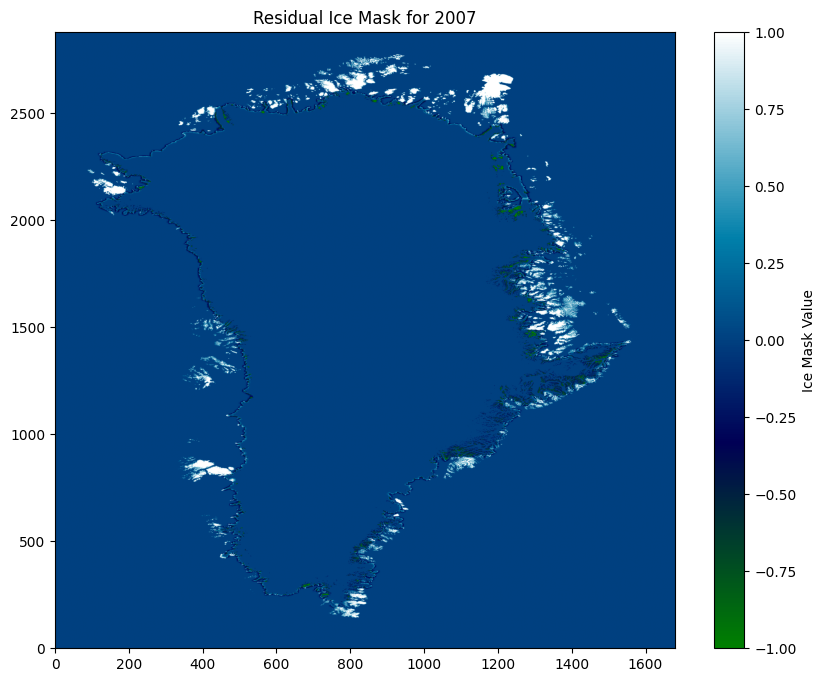

interactive(children=(FloatSlider(value=2007.0, description='Year:', max=2010.0, min=2007.0, step=1.0), Output…

<function __main__.plot_time_residuals(year)>

In [ ]:
data = residuals.ds.sel(year=year)
data = data.residual.values  # Extract the residual values for the specified year
print(f"Data shape for year {year}: {data.shape}")

rotated_data = rotated_data_year(residuals, year)
# im = plt.imshow(rotated_data, cmap=cmap, origin='upper', aspect=aspect)

def plot_time_residuals(year):
    try:
        plt.clf()
        plt.figure(figsize=(10, 8))
        im = plt.imshow(rotated_data, cmap=cmap, origin='lower', aspect=aspect)

        plt.title(f"Residual Ice Mask for {year}")
        plt.colorbar(im, label='Ice Mask Value')
        
        plt.show()
        
        # Clean up plot objects
        plt.close('all')
        gc.collect()
        
    except Exception as e:
        print(f"Error plotting year {year}: {e}")
        print(f"Available years in dataset: {gsfc_ds_residual.year.values}")

print("Testing plot function...")
plot_time_residuals(start_year)

time_slider = FloatSlider(
    value=start_year, 
    min=start_year, 
    max=end_year, 
    step=1, 
    description='Year:', 
    continuous_update=True
)


interact(plot_time_residuals, year=time_slider)


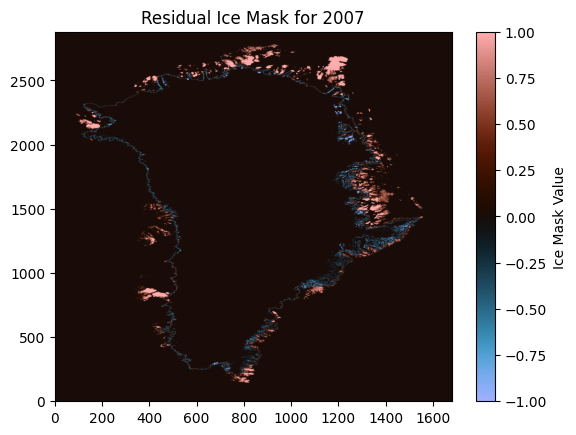

In [16]:
# Plotting the residual for the specified year
rotated_data = np.rot90(data, k=0)

plt.imshow(rotated_data, cmap='berlin', origin='lower', aspect='auto')
plt.title(f"Residual Ice Mask for {year}")
plt.colorbar(label='Ice Mask Value')

# Aggregating based on Basin Shape

## Plotting and Fitting Shape File

In [17]:
if not basin_aggregation:
    exit("Basin aggregation is not enabled. Please set basin_aggregation to True to proceed with basin-wise plotting.")

In [18]:
from cmct.shapefile_utils import *

gdf_shape, new_gdf_shape, rotated_data_shape = fit_basins_per_year(residuals, basin_aggregation=True, shape_file=basin_shapes, year=year)

print("")
print(f"Shape File Shape: {gdf_shape}")
print(f"New Shape File Shape: {new_gdf_shape}")




Conversion complete. CRS: EPSG:3413
Number of interpolated points: 413300

Shape File Shape: [-271477345.7969532, 77076936.48637094, -206322219.393696, 178821104.88569322]
New Shape File Shape: [87.0, 1560.0000000000002, 141.0, 2776.0]


## Recognizing Separate Basins

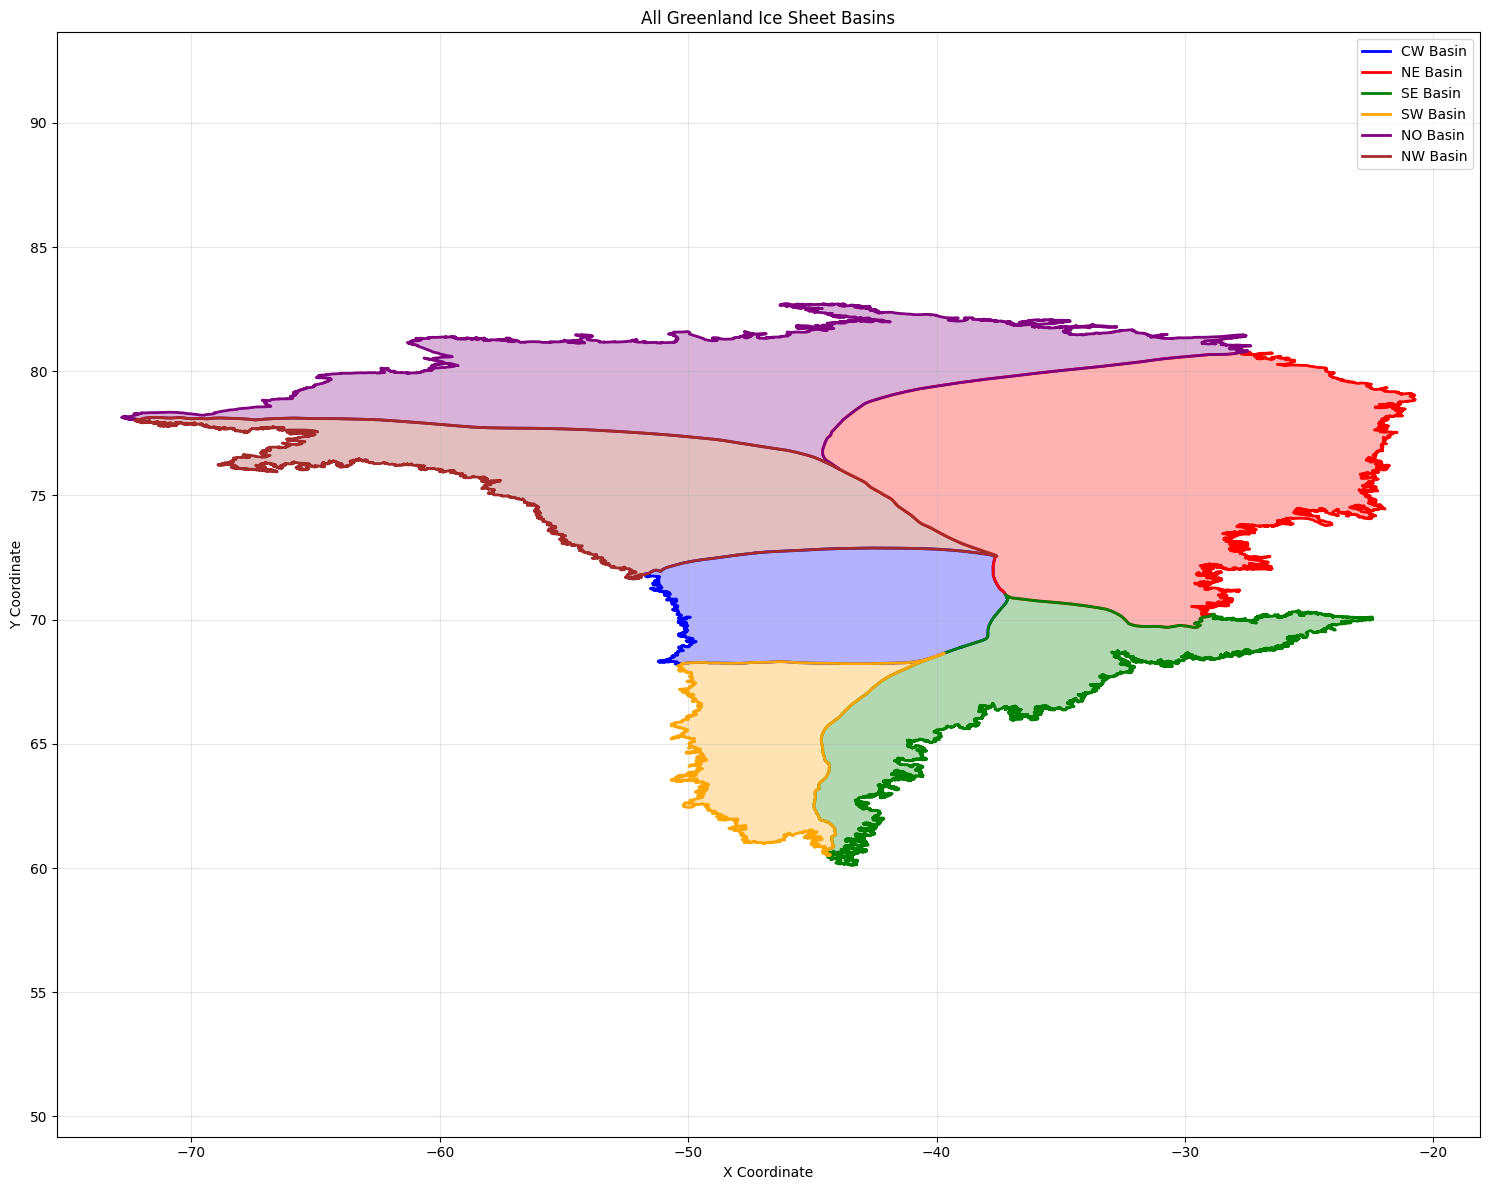

In [19]:
# Plotting all the basins - Fixed version
plt.figure(figsize=(15, 12))

# Check if basins is a tuple or dict and handle accordingly
if isinstance(basins, tuple):
    basin_dict = basins[0] if len(basins) > 0 else {}
elif isinstance(basins, dict):
    basin_dict = basins
else:
    print(f"Unexpected basins type: {type(basins)}")
    basin_dict = {}

# Plot each basin
for basin_name, basin_data in basin_dict.items():
    # Extract coordinates from the polygon
    if hasattr(basin_data, 'exterior'):
        # basin_data is a Polygon object
        x_coords, y_coords = basin_data.exterior.xy
    else:
        # basin_data is a dictionary with x, y coordinates
        x_coords = basin_data["x"]
        y_coords = basin_data["y"]
    
    # Get color for this basin, use a default if not found
    basin_color = colors.get(basin_name, 'gray')
    
    # Plot the basin outline
    plt.plot(x_coords, y_coords, 
             linewidth=2, color=basin_color,
             label=f'{basin_name} Basin')
    
    # Fill the basin polygon for better visualization
    plt.fill(x_coords, y_coords, color=basin_color,
             alpha=0.3)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('All Greenland Ice Sheet Basins')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')  # Equal aspect ratio
plt.tight_layout()
plt.show()

# Aggregation to basins for all years 


In [20]:
basin_dataset = aggregating_basins(residuals, basins, years=range(start_year, end_year + 1))
gc.collect()

2025-07-14 12:21:20,585 - INFO - Processing year 2007...
2025-07-14 12:23:17,877 - INFO - Year 2007: 4,838,400 valid points, 0 assigned to basins
2025-07-14 12:23:17,949 - INFO - Processing year 2008...
2025-07-14 12:25:14,088 - INFO - Year 2008: 4,838,400 valid points, 0 assigned to basins
2025-07-14 12:25:14,163 - INFO - Processing year 2009...
2025-07-14 12:27:10,380 - INFO - Year 2009: 4,838,400 valid points, 0 assigned to basins
2025-07-14 12:27:10,458 - INFO - Processing year 2010...
2025-07-14 12:29:07,483 - INFO - Year 2010: 4,838,400 valid points, 0 assigned to basins


0

In [ ]:
if isinstance(basins, tuple):
    basin_dict = basins[0] if len(basins) > 0 else {}
elif isinstance(basins, dict):
    basin_dict = basins
else:
    print(f"Unexpected basins type: {type(basins)}")
    basin_dict = {}

standardized_basins = standardize_basin_projection(basin_dict, gsfc)

# Update basins variable with standardized version
if isinstance(basins, tuple):
    basins = (standardized_basins, basins[1])
else:
    basins = standardized_basins

print("Basin standardization complete. Re-running basin aggregation...")

# Re-run basin aggregation with standardized basins
basin_dataset = aggregating_basins(residuals, standardized_basins, years=range(start_year, end_year + 1))
gc.collect()

Standardizing basin projections...
Data coordinate bounds: X=[-719500, 959500], Y=[-3449500, -570500]
Converting CW from lat/lon to ISMIP6 projection...
CW: X=[-256826, 287152], Y=[-2385414, -1864514]
Converting NE from lat/lon to ISMIP6 projection...
NE: X=[10363, 664864], Y=[-2159168, -953496]
Converting SE from lat/lon to ISMIP6 projection...


2025-07-14 12:39:07,810 - INFO - Processing year 2007...


SE: X=[3325, 839104], Y=[-3309066, -2010006]
Converting SW from lat/lon to ISMIP6 projection...
SW: X=[-289046, 216672], Y=[-3264606, -2328905]
Converting NO from lat/lon to ISMIP6 projection...
NO: X=[-601436, 300724], Y=[-1517669, -789966]
Converting NW from lat/lon to ISMIP6 projection...
NW: X=[-607916, 245897], Y=[-1990296, -1151989]
Standardized 6 basins
Basin standardization complete. Re-running basin aggregation...


2025-07-14 12:40:51,836 - INFO - Year 2007: 4,838,400 valid points, 1,725,984 assigned to basins
2025-07-14 12:40:51,912 - INFO - Processing year 2008...
2025-07-14 12:42:34,103 - INFO - Year 2008: 4,838,400 valid points, 1,725,984 assigned to basins
2025-07-14 12:42:34,188 - INFO - Processing year 2009...


KeyboardInterrupt: 

Creating overlay plot of residuals and basin boundaries...


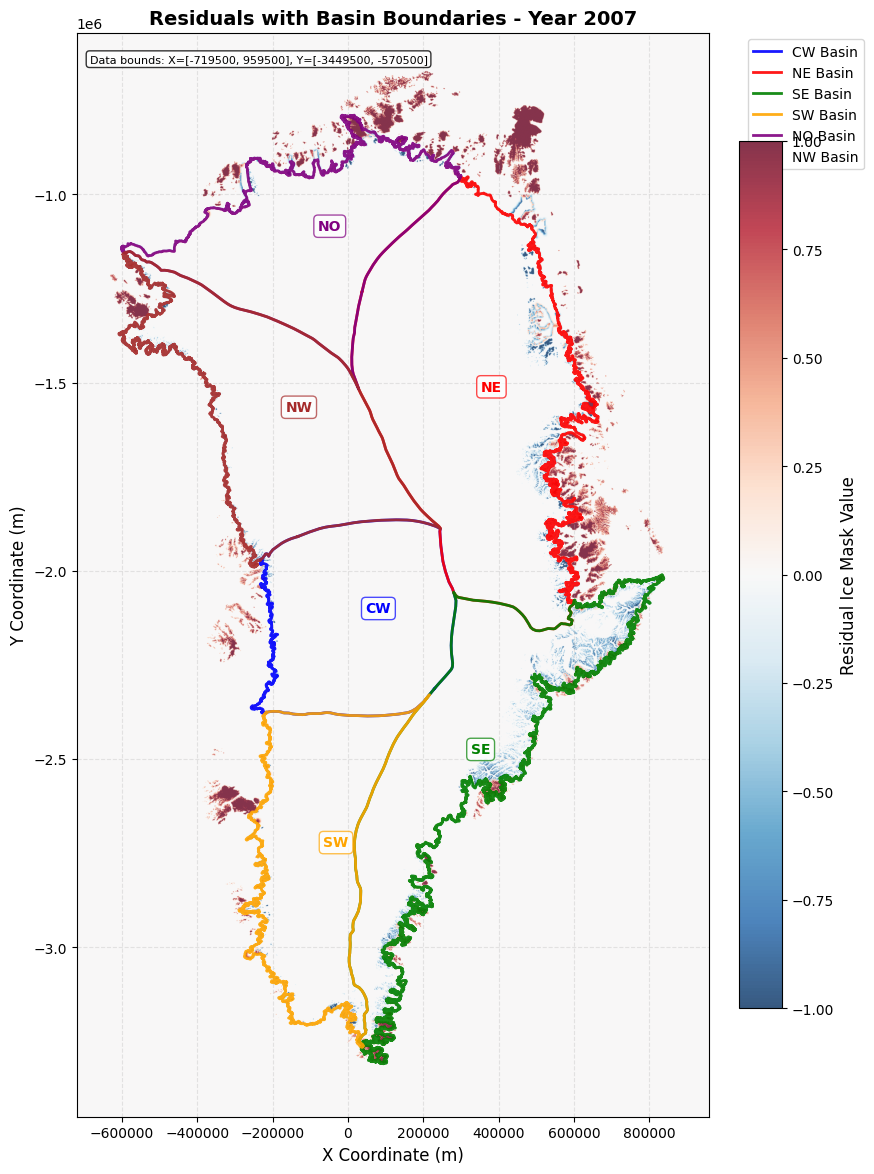


Basin Coverage Analysis for Year 2007:
Total non-NaN data points: 4838400
          CW:      0 points (  0.0% coverage)
          NE:      0 points (  0.0% coverage)
          SE:      0 points (  0.0% coverage)
          SW:      0 points (  0.0% coverage)
          NO:      0 points (  0.0% coverage)
          NW:      0 points (  0.0% coverage)

Interactive overlay plot (Years 2007-2010):


interactive(children=(FloatSlider(value=2007.0, continuous_update=False, description='Year:', max=2010.0, min=…

<function __main__.interactive_overlay_plot(year)>

In [ ]:
# Use the standardized basins if available, otherwise use original basins
plot_basins = standardized_basins if 'standardized_basins' in locals() else (
    basins[0] if isinstance(basins, tuple) else basins
)

# Plot for the first year in the range
plot_year = start_year
plot_residuals_with_basins(residuals, plot_basins, plot_year)

# Create an interactive version with year slider
def interactive_overlay_plot(year):
    """Interactive version of the overlay plot"""
    plot_residuals_with_basins(residuals, plot_basins, year, figsize=(12, 10))

print(f"\nInteractive overlay plot (Years {start_year}-{end_year}):")
year_slider = FloatSlider(
    value=start_year, 
    min=start_year, 
    max=end_year, 
    step=1, 
    description='Year:', 
    continuous_update=False  # Set to False to reduce computational load
)

interact(interactive_overlay_plot, year=year_slider)

In [ ]:
# Verify basin assignment and re-aggregate if needed
print("Verifying basin assignment with corrected projections...")

# Check if we have the standardized basins and proper aggregation
if 'standardized_basins' in locals():
    print(f"Using standardized basins: {list(standardized_basins.keys())}")
    
    # Re-run basin aggregation with the corrected basins
    print("Re-running basin aggregation with corrected projections...")
    basin_dataset = aggregating_basins(residuals, standardized_basins, years=range(start_year, end_year + 1))
    
    # Verify the results
    if basin_dataset:
        print("\nBasin aggregation successful! Summary:")
        for year in range(start_year, min(start_year + 2, end_year + 1)):  # Show first 2 years
            if year in basin_dataset:
                print(f"\nYear {year}:")
                for basin_name, basin_data in basin_dataset[year].items():
                    if 'data_value' in basin_data:
                        point_count = len(basin_data['data_value'])
                        if point_count > 0:
                            mean_val = np.mean(basin_data['data_value'])
                            print(f"  {basin_name}: {point_count} points, mean residual = {mean_val:.4f}")
                        else:
                            print(f"  {basin_name}: 0 points")
    
    # Update the plot with corrected data
    print("\nUpdating basin coverage statistics...")
    
    # Recalculate coverage for the plot
    year = start_year
    if basin_dataset and year in basin_dataset:
        residual_year_data = residuals.ds.sel(year=year)
        rotated_data = rotated_data_year(residuals, year)
        total_data_points = np.sum(~np.isnan(rotated_data))
        
        print(f"\nCorrected Basin Coverage for Year {year}:")
        print("=" * 50)
        print(f"Total non-NaN data points: {total_data_points}")
        
        for basin_name in standardized_basins.keys():
            if basin_name in basin_dataset[year]:
                basin_points = len(basin_dataset[year][basin_name]['data_value'])
                coverage_pct = (basin_points / total_data_points) * 100 if total_data_points > 0 else 0
                print(f"{basin_name:>12}: {basin_points:>6} points ({coverage_pct:>5.1f}% coverage)")
        
        # Check for unassigned points
        assigned_points = sum(len(basin_dataset[year][basin]['data_value']) 
                            for basin in basin_dataset[year] if basin in standardized_basins)
        unassigned_points = total_data_points - assigned_points
        unassigned_pct = (unassigned_points / total_data_points) * 100 if total_data_points > 0 else 0
        print(f"{'Unassigned':>12}: {unassigned_points:>6} points ({unassigned_pct:>5.1f}% coverage)")
        
else:
    print("Standardized basins not found. Please run the standardization cell first.")

gc.collect()

## Calculating Basin Statistics per Year 

In [21]:
stats = calculate_basin_statistics(basin_dataset)
gc.collect()


print("Basin Statistics Summary:")
print("=" * 80)

for year in sorted(stats.keys()):
    print(f"\nYear {year}:")
    print(f"{'Basin':<12} {'Count':<8} {'Sum':<10} {'Mean':<10} {'Std':<10} {'Min':<10} {'Max':<10} {'RMS':<10} {'RSS':<10} {'Winsorized Mean':<10} {'Outlier Weighted Mean':<10}")
    print("-" * 80)
    
    for basin_name in ['CW', 'NE', 'SE', 'SW', 'NO', 'NW']:
        if basin_name in stats[year]:
            s = stats[year][basin_name]
            print(f"{basin_name:<12} {s['count']:<8} {s['sum']:<10.4f} {s['mean']:<10.4f} {s['std']:<10.4f} "
                  f"{s['min']:<10.4f} {s['max']:<10.4f} {s['rms']:<10.4f} {s['rss']:<10.4f} {s['winsorized_mean']:<10.4f} {s['outlier_weighted_mean']:<10.4f}")

    if 'unassigned' in stats[year]:
        s = stats[year]['unassigned']
        print(f"{'unassigned':<12} {s['count']:<8} {s['sum']:<10.4f} {s['mean']:<10.4f} {s['std']:<10.4f} "
              f"{s['min']:<10.4f} {s['max']:<10.4f} {s['rms']:<10.4f} {s['rss']:<10.4f} {s['winsorized_mean']:<10.4f} {s['outlier_weighted_mean']:<10.4f}")

Basin Statistics Summary:

Year 2007:
Basin        Count    Sum        Mean       Std        Min        Max        RMS        RSS        Winsorized Mean Outlier Weighted Mean
--------------------------------------------------------------------------------
unassigned   4838400  50658.1133 0.0105     0.1315     -1.0000    1.0000     0.1319     84212.9688 0.0000     0.4065    

Year 2008:
Basin        Count    Sum        Mean       Std        Min        Max        RMS        RSS        Winsorized Mean Outlier Weighted Mean
--------------------------------------------------------------------------------
unassigned   4838400  50404.8281 0.0104     0.1314     -1.0000    1.0000     0.1318     84084.1484 0.0000     0.4050    

Year 2009:
Basin        Count    Sum        Mean       Std        Min        Max        RMS        RSS        Winsorized Mean Outlier Weighted Mean
--------------------------------------------------------------------------------
unassigned   4838400  50058.9609 0.0103   

In [22]:
make_time_residual_plots(stats, colors, basin_list)


NameError: name 'make_time_residual_plots' is not defined

# Dataset Output Configuration [IN PROGRESS]

In [ ]:
# from cmct.calving_modules.json_to_netcdf import json_to_netcdf
# # If you would like to get an output file, set it up in the configuration code.
# if filetype == 'json':
#     output_filename = cmct_dir + f'/notebooks/Calving/{filename}.json'
#     json.dump(residuals_list, open(cmct_dir + '/notebooks/Calving/residuals.json', 'w'))
# elif filetype == 'netcdf':
#     output_filename = cmct_dir + f'/notebooks/Calving/{filename}.nc'
    
#     # GSFC Residual is a version of gsfc with the residuals
#     gsfc_ds_residual = json_to_netcdf(residuals_list)
#     gsfc_ds_residual.to_netcdf(output_filename, mode='w', format='NETCDF4')
#     logging.info(f"Saved NetCDF file to {output_filename}")
#     print(f"Dataset saved to: {output_filename}")
# else:
#     logging.info("Dataset created in memory, ready for plotting")
#     print("Dataset created in memory and ready for use")

# print(f"Dataset shape: {gsfc_ds_residual.dims}")
# print(f"Available variables: {list(gsfc_ds_residual.data_vars.keys())}")
# print(f"Coordinate dimensions: {list(gsfc_ds_residual.coords.keys())}") 